## Model evauation and visualization

In [1]:
from scripts import Spark_Init as spi
spark = spi.start_spark("Data Evaluation")

Library location check:
Spark home: C:\Users\senza\Desktop\Projects\PersonalProjects\PythonProjects\MyMLClassProject\content\spark-3.5.1-bin-hadoop3
Java home: C:\Users\senza\Desktop\Projects\PersonalProjects\PythonProjects\MyMLClassProject\content\java\jdk-17
hadoop home: C:\Users\senza\Desktop\Projects\PersonalProjects\PythonProjects\MyMLClassProject\content\hadoop
Spark Session 'Data Evaluation' is active!
Spark UI available at: http://10.223.136.209:4040


In [2]:
from pyspark.ml.regression import GBTRegressionModel, LinearRegressionModel, RandomForestRegressionModel
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# fare_vs_distance = spark.sql("""
#     SELECT trip_distance, fare_amount
#     FROM nyc_yellow_cab_data
#     WHERE trip_distance < 50
# """)
# fare_vs_distance_df = fare_vs_distance.toPandas()

In [3]:
# If GBT was your winner:
model_name_path = "GBT_Regressor"
loaded_model = GBTRegressionModel.load(f"../data/trained/saved_models/{model_name_path}_model")

In [4]:
df_predictions = spark.read.parquet(f"../data/saved_predictions/{model_name_path}_predictions")

In [5]:
df_predictions.printSchema()

root
 |-- fare_amount: double (nullable = true)
 |-- prediction: double (nullable = true)



## Features Importance

In [14]:
feature_cols = ["PULocationID", "VendorID", "passenger_count", "trip_distance", "RatecodeID",
                  "DOLocationID", "payment_type", "extra", "mta_tax", "tip_amount",
                  "tolls_amount", "improvement_surcharge", "congestion_surcharge",
                  "Airport_fee", "pickup_hour", "pickup_dayofweek", "pickup_month",
                  "pickup_year", "trip_duration", "distance_per_passenger",
                  "fare_per_distance", "total_per_passenger", "avg_fare_by_location",
                  "avg_duration_by_location"]

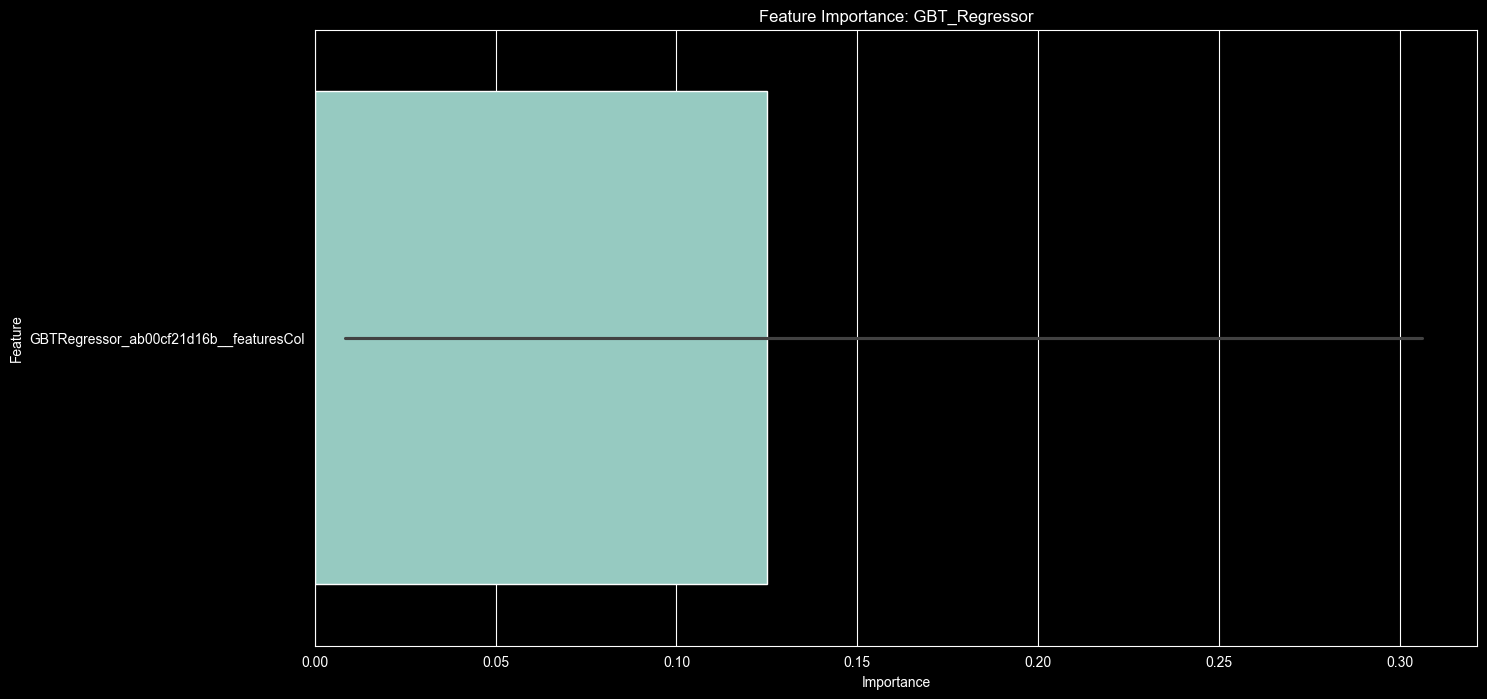

In [42]:
def plot_importance(model_name):
    # Find the model in our log
    # entry = next(item for item in experiment_log if item["Model"] == model_name)
    model = loaded_model#entry["Model_Obj"]

    if hasattr(model, "featureImportances"):
        importances = model.featureImportances.toArray()
        feat_df = pd.DataFrame({'Feature': model.numFeatures, 'Importance': importances})
        feat_df = feat_df.sort_values(by='Importance', ascending=False)

        plt.figure(figsize=(15, 8))
        sns.barplot(x='Importance', y='Feature', data=feat_df)
        plt.title(f'Feature Importance: {model_name}')
        plt.show()

plot_importance("GBT_Regressor")

## Learning Curves (Prediction vs. Actual)
**For regression, this replaces the Confusion Matrix to show where the model "guesses" wrong**

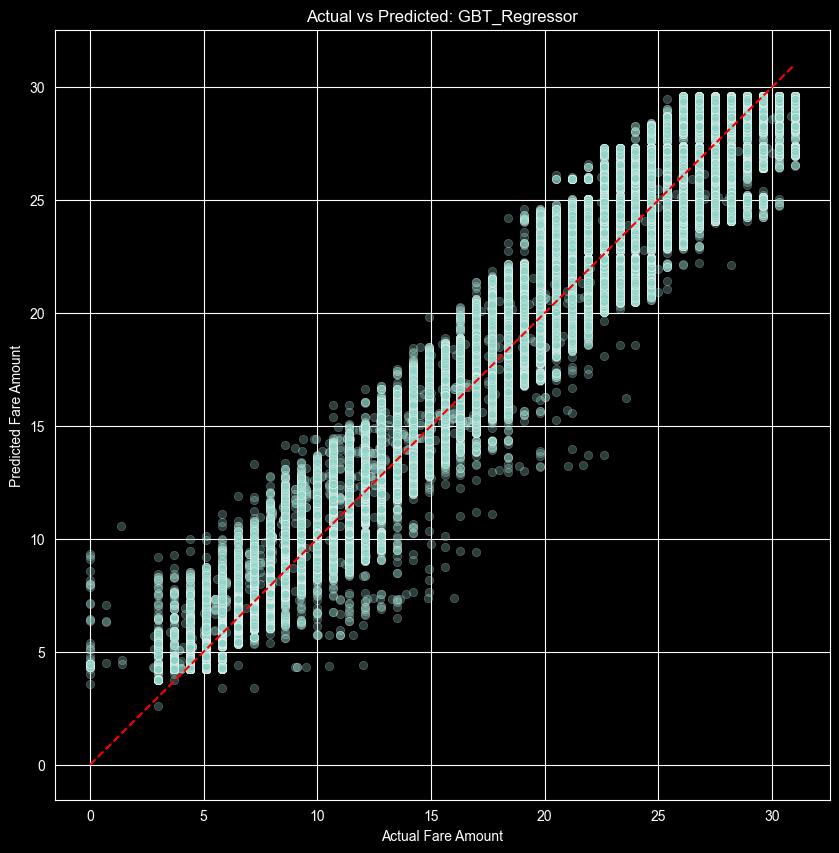

In [43]:
def plot_regression_results(model_name):
    entry = loaded_model#next(item for item in experiment_log if item["Model"] == model_name)
    pdf = df_predictions.toPandas()#entry["Predictions"]

    plt.figure(figsize=(10, 10))
    sns.scatterplot(x='fare_amount', y='prediction', data=pdf, alpha=0.3)
    plt.plot([pdf.fare_amount.min(), pdf.fare_amount.max()],
             [pdf.fare_amount.min(), pdf.fare_amount.max()], 'r--')
    plt.title(f'Actual vs Predicted: {model_name}')
    plt.xlabel('Actual Fare Amount')
    plt.ylabel('Predicted Fare Amount')
    plt.show()

plot_regression_results("GBT_Regressor")

**prices will continue to see a steady increase in price**

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Training_Time_Sec', y='RMSE', hue='Model', s=200, data=results_df)
plt.title("Trade-off: Training Speed vs. Accuracy")
plt.show()

In [ ]:
from scipy import stats

# Get residuals for top two models
m1_res = (results_df.iloc[0]['Predictions']['total_amount'] - results_df.iloc[0]['Predictions']['prediction'])**2
m2_res = (results_df.iloc[1]['Predictions']['total_amount'] - results_df.iloc[1]['Predictions']['prediction'])**2

t_stat, p_val = stats.ttest_rel(m1_res, m2_res)
print(f"Statistical Significance (p-value): {p_val:.5f}")
# If p < 0.05, the difference is significant!